### Step 1: Data Collection & Loading

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [86]:
df = pd.read_csv("airline_passenger_satisfaction.csv")

In [87]:
df.shape

(129880, 24)

In [88]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


###  Step 2: Initial Data Inspection

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

In [90]:
df.describe()

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [91]:
df.isnull().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

In [92]:
df.duplicated().sum()

np.int64(0)

In [93]:
df.nunique()

ID                                        129880
Gender                                         2
Age                                           75
Customer Type                                  2
Type of Travel                                 2
Class                                          3
Flight Distance                             3821
Departure Delay                              466
Arrival Delay                                472
Departure and Arrival Time Convenience         6
Ease of Online Booking                         6
Check-in Service                               6
Online Boarding                                6
Gate Location                                  6
On-board Service                               6
Seat Comfort                                   6
Leg Room Service                               6
Cleanliness                                    6
Food and Drink                                 6
In-flight Service                              6
In-flight Wifi Servi

### Step 3: Data Cleaning

In [94]:
df = df.drop_duplicates()

In [95]:
df["Arrival Delay"] = df["Arrival Delay"].fillna(df["Arrival Delay"].median())

In [96]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

In [97]:
df.columns

Index(['id', 'gender', 'age', 'customer_type', 'type_of_travel', 'class',
       'flight_distance', 'departure_delay', 'arrival_delay',
       'departure_and_arrival_time_convenience', 'ease_of_online_booking',
       'check-in_service', 'online_boarding', 'gate_location',
       'on-board_service', 'seat_comfort', 'leg_room_service', 'cleanliness',
       'food_and_drink', 'in-flight_service', 'in-flight_wifi_service',
       'in-flight_entertainment', 'baggage_handling', 'satisfaction'],
      dtype='object')

In [98]:
df = df.drop("id", axis=1)

In [99]:
df.columns

Index(['gender', 'age', 'customer_type', 'type_of_travel', 'class',
       'flight_distance', 'departure_delay', 'arrival_delay',
       'departure_and_arrival_time_convenience', 'ease_of_online_booking',
       'check-in_service', 'online_boarding', 'gate_location',
       'on-board_service', 'seat_comfort', 'leg_room_service', 'cleanliness',
       'food_and_drink', 'in-flight_service', 'in-flight_wifi_service',
       'in-flight_entertainment', 'baggage_handling', 'satisfaction'],
      dtype='object')

### Step 4: Exploratory Data Analysis (EDA)

### Univariate Analysis

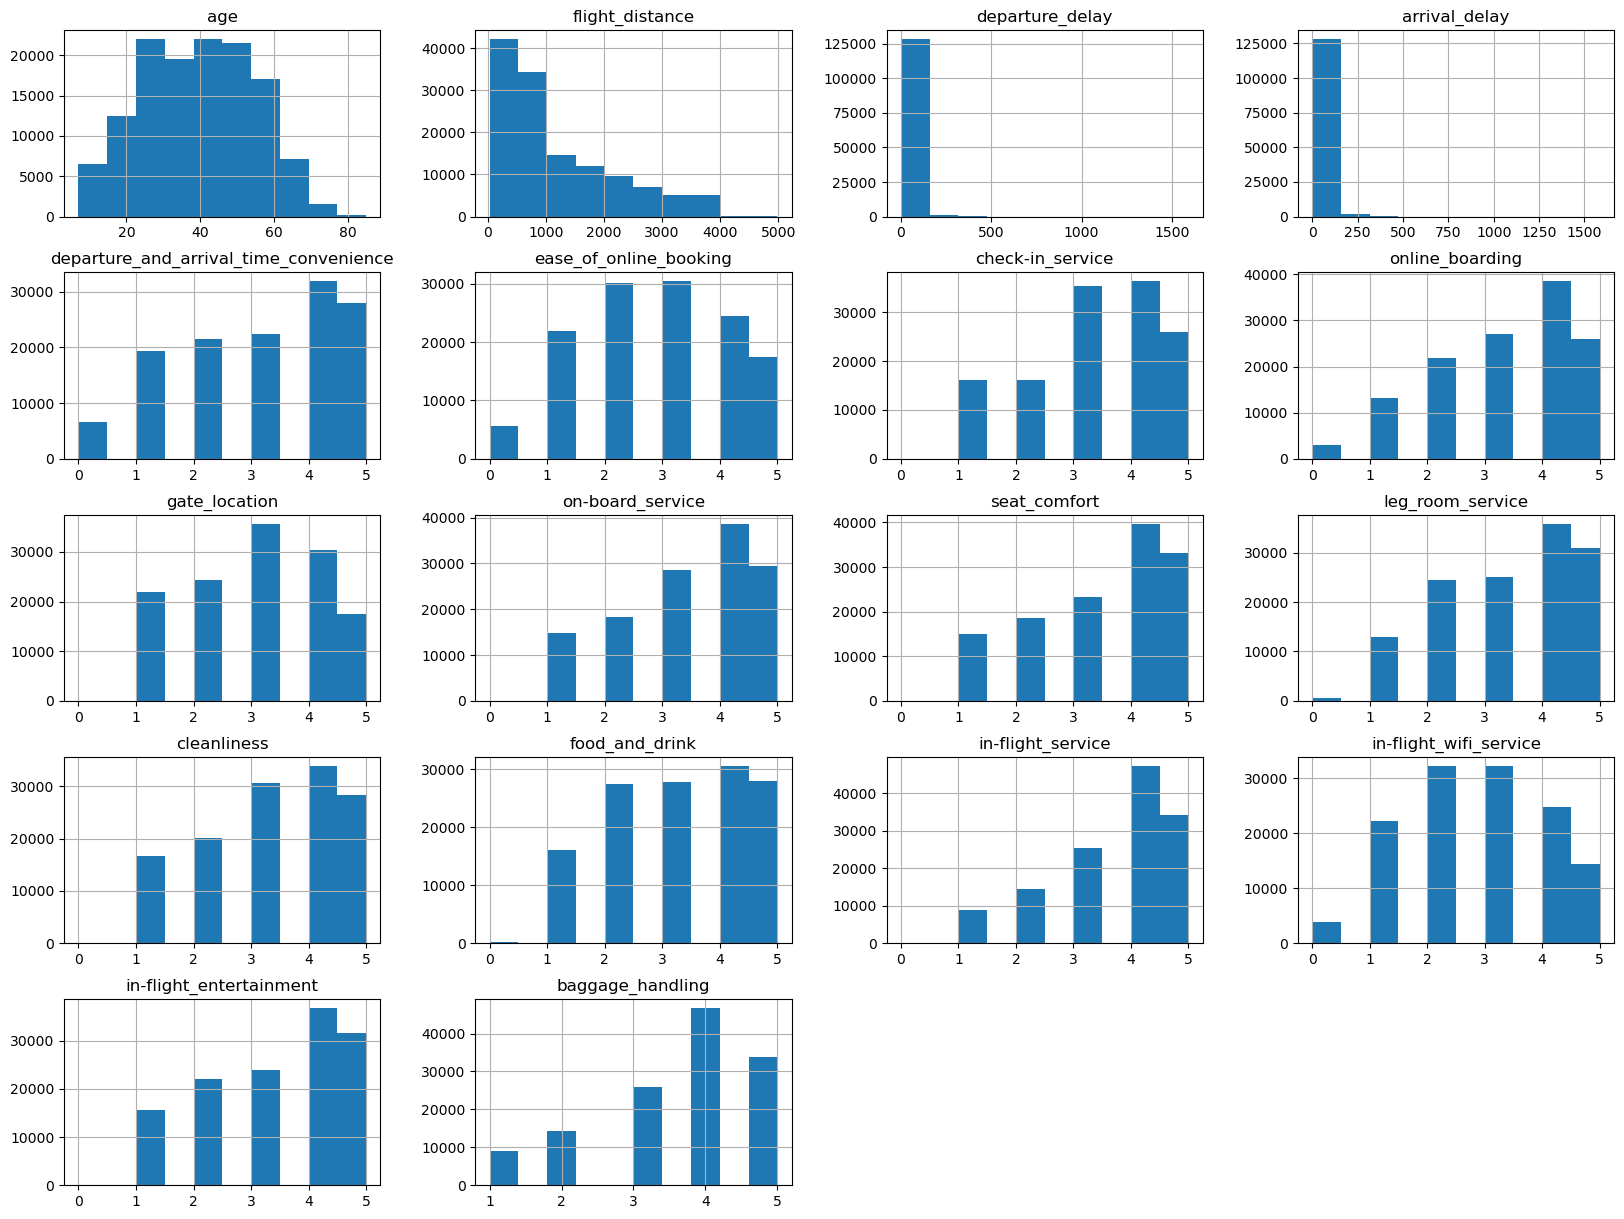

In [100]:
df.hist(figsize=(20,15))
plt.show()

In [101]:
# Skewness
df.skew(numeric_only=True)

age                                      -0.003606
flight_distance                           1.108142
departure_delay                           6.821980
arrival_delay                             6.678957
departure_and_arrival_time_convenience   -0.332469
ease_of_online_booking                   -0.018779
check-in_service                         -0.366569
online_boarding                          -0.456911
gate_location                            -0.058265
on-board_service                         -0.421320
seat_comfort                             -0.485818
leg_room_service                         -0.348414
cleanliness                              -0.300926
food_and_drink                           -0.155063
in-flight_service                        -0.691580
in-flight_wifi_service                    0.040465
in-flight_entertainment                  -0.366385
baggage_handling                         -0.677400
dtype: float64

### Bivariate Analysis

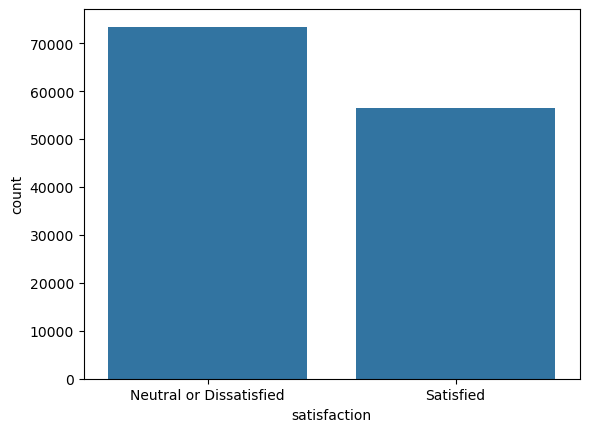

In [102]:
sns.countplot(x="satisfaction", data=df)
plt.show()

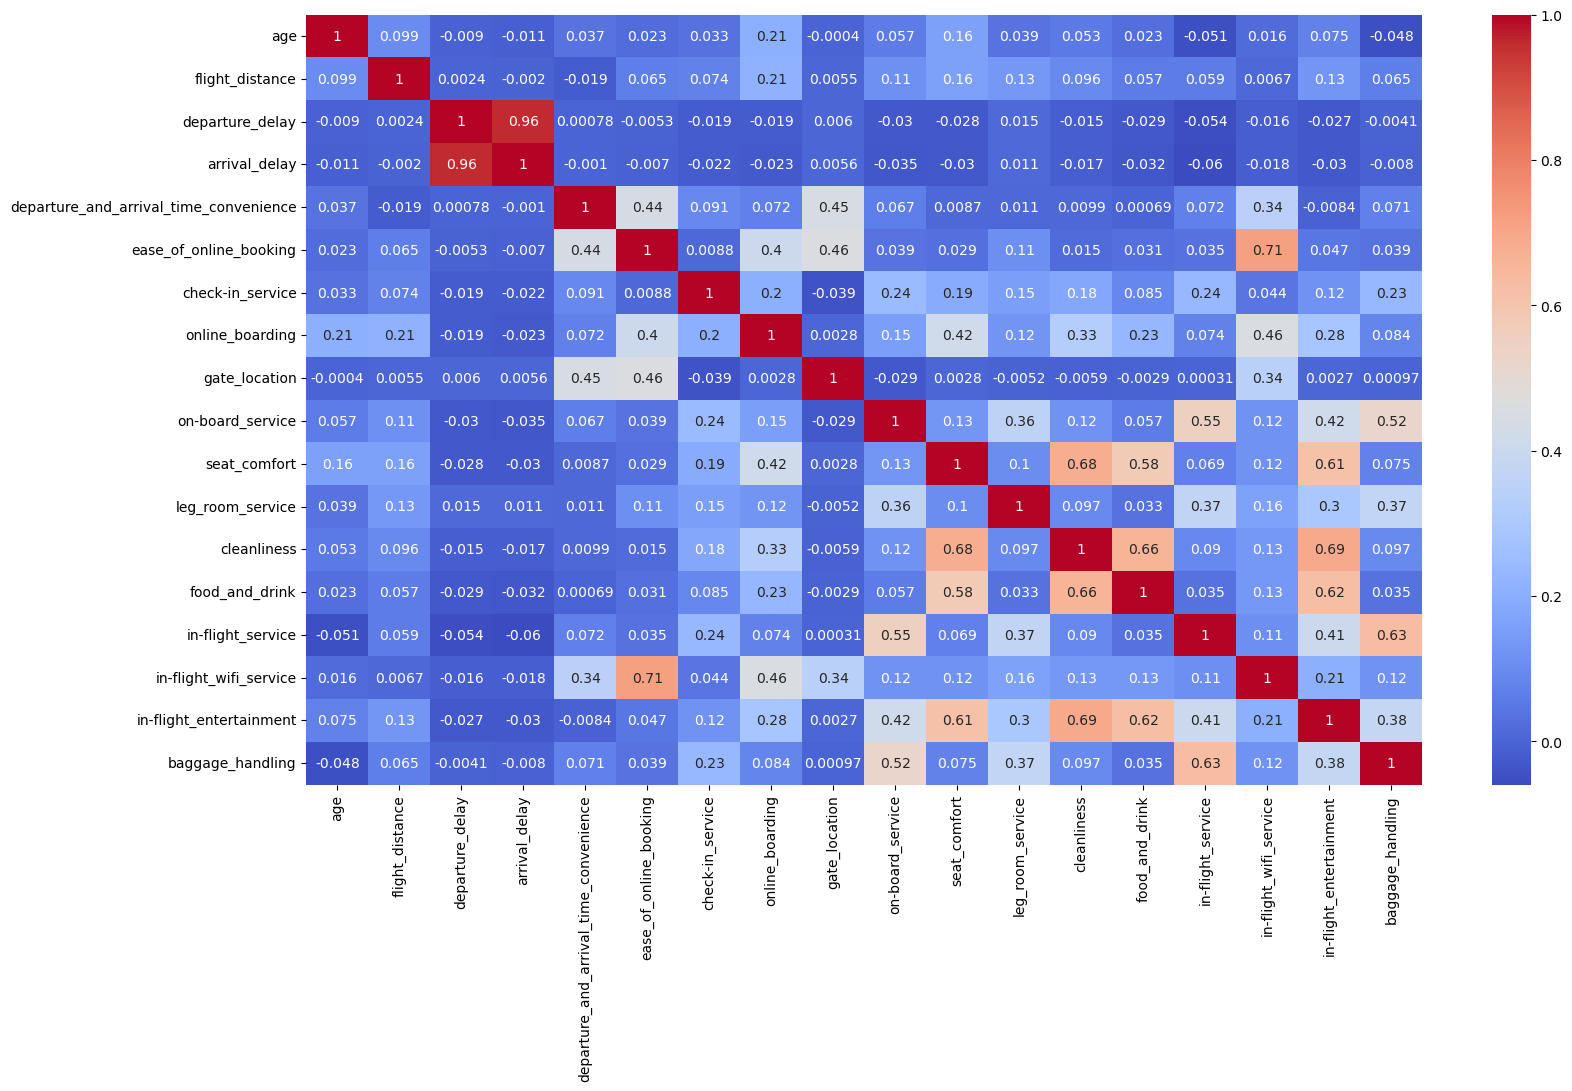

In [103]:
plt.figure(figsize=(18,10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.show()

### Multivariate Analysis

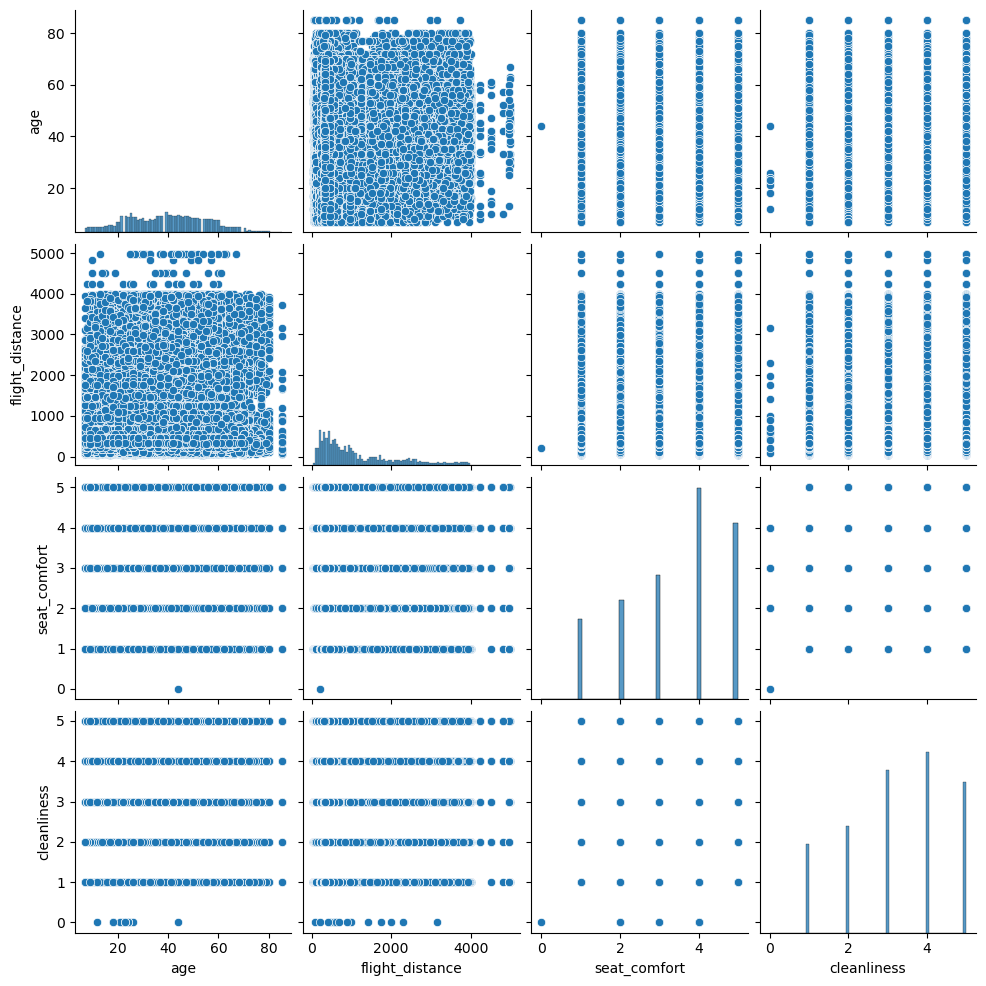

In [104]:
sns.pairplot(df[['age',
                 'flight_distance',
                 'seat_comfort',
                 'cleanliness',
                 'satisfaction']])
plt.show()

### Step 5: Outlier Detection & Treatment

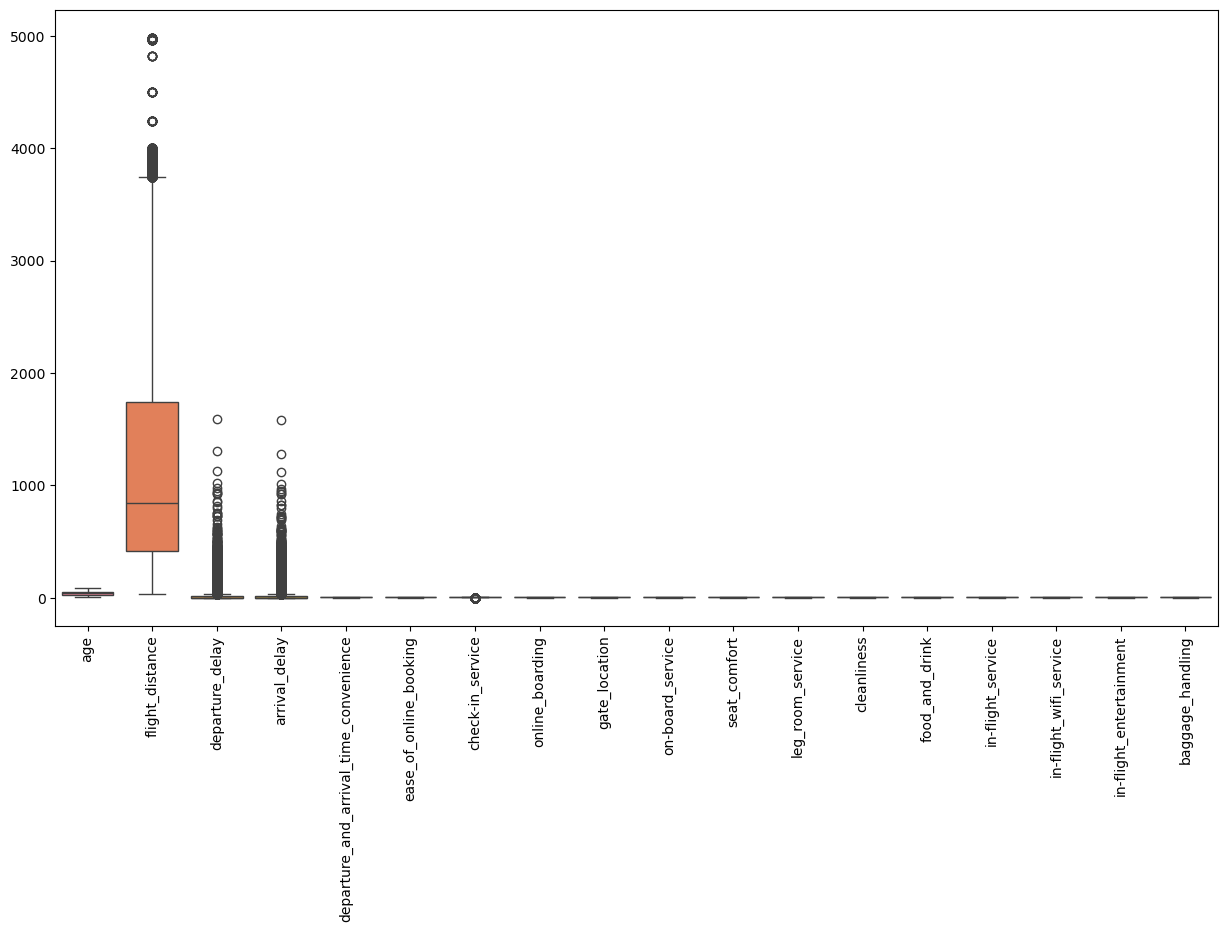

In [105]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()

cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

In [106]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

In [107]:
print("Shape After Outlier Removal:",df.shape)

Shape After Outlier Removal: (74621, 23)


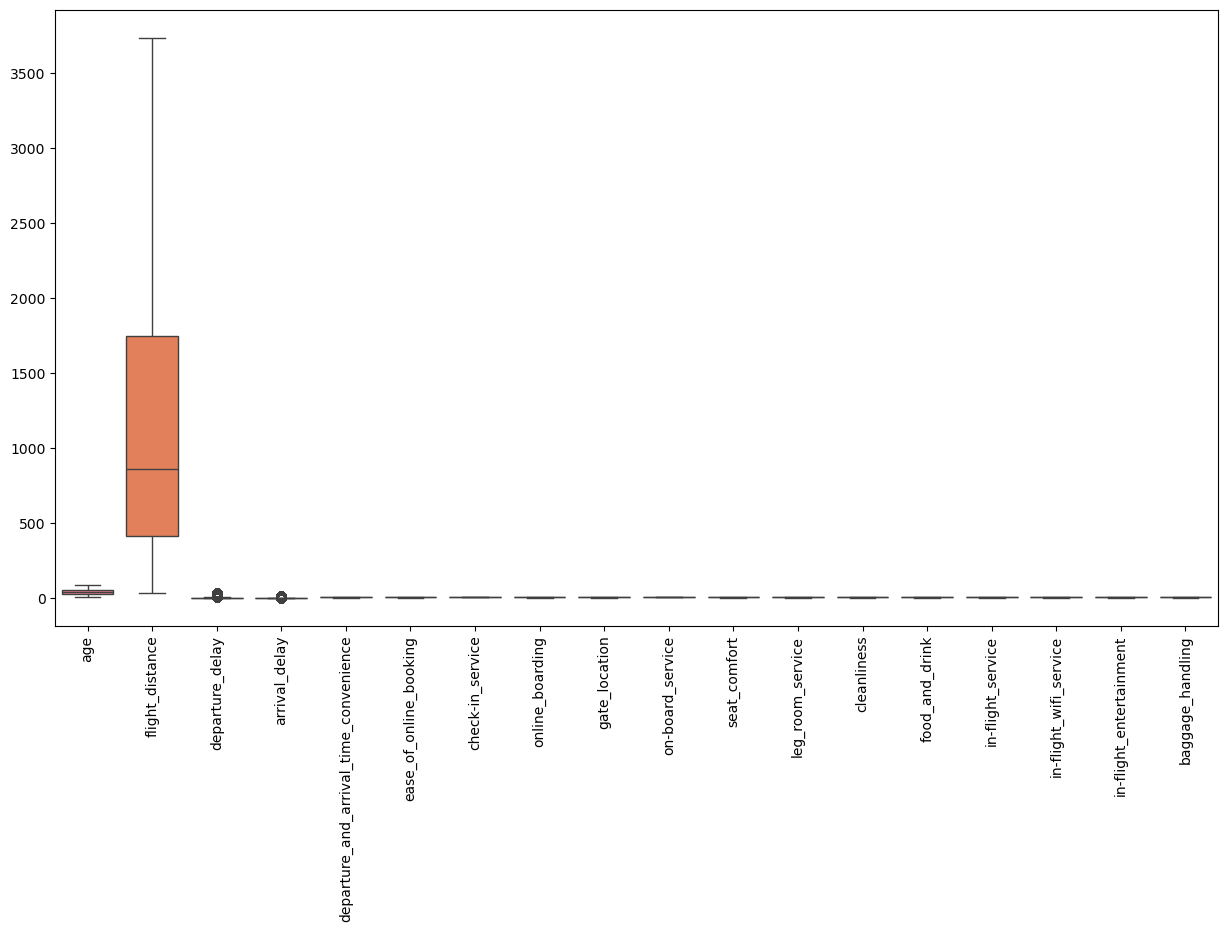

In [108]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)

plt.show()

### Step 6: Feature Encoding

In [109]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:

    df[col] = le.fit_transform(df[col])

In [110]:
df.head()

,gender,age,customer_type,type_of_travel,class,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,ease_of_online_booking,...,on-board_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,in-flight_service,in-flight_wifi_service,in-flight_entertainment,baggage_handling,satisfaction
0,1,48,0,0,0,821,2,5.0,3,3,...,3,5,2,5,5,5,3,5,5,0
2,1,41,1,0,0,853,0,0.0,4,4,...,3,5,3,5,5,3,4,3,3,1
3,1,50,1,0,0,1905,0,0.0,2,2,...,5,5,5,4,4,5,2,5,5,1
4,0,49,1,0,0,3470,0,1.0,3,3,...,3,4,4,5,4,3,3,3,3,1
6,1,43,1,0,0,1963,0,0.0,3,3,...,5,5,5,4,5,5,3,5,5,1


### Step 7: Feature Scaling

In [111]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [113]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [114]:
### Step 8: Train-Test Split

In [115]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (59696, 22)
X_test Shape  : (14925, 22)
y_train Shape : (59696,)
y_test Shape  : (14925,)


## SPRINT 2: MODEL BUILDING & EVALUATION

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [117]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [118]:
y_pred_lr = lr.predict(X_test)

In [119]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.8720938023450586


In [120]:
## Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.9438525963149079


In [121]:
## Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9565829145728644


In [122]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy :", svm_accuracy)

SVM Accuracy : 0.9478056951423786


In [123]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.8554773869346733


### Step 3: Model Evaluation

### Logistic Regression Evaluation

In [124]:
print("Classification Report")
print(classification_report(y_test, y_pred_lr))

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      7369
           1       0.89      0.86      0.87      7556

    accuracy                           0.87     14925
   macro avg       0.87      0.87      0.87     14925
weighted avg       0.87      0.87      0.87     14925



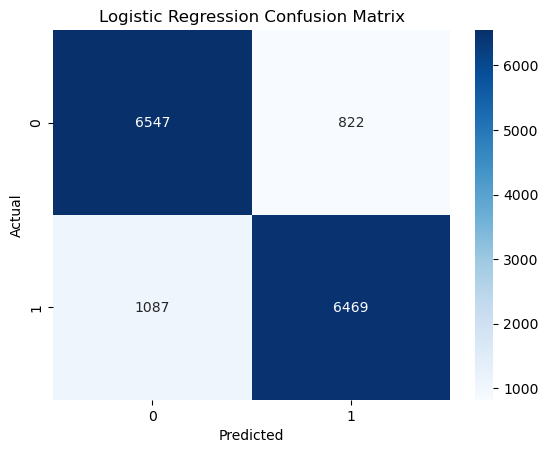

In [125]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

###  Step 4: Overfitting & Underfitting Check

In [126]:
# Training Accuracy

train_lr = lr.score(X_train, y_train)

# Testing Accuracy

test_lr = lr.score(X_test, y_test)

print("Training Accuracy :", train_lr)

print("Testing Accuracy :", test_lr)

Training Accuracy : 0.8773284642187081
Testing Accuracy : 0.8720938023450586


### Step 5: Model Comparison Table

In [127]:
# Create Comparison Table
model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Naive Bayes"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        nb_accuracy
    ]
})
model_comparison

,Model,Accuracy
0,Logistic Regression,0.872094
1,Decision Tree,0.943853
2,Random Forest,0.956583
3,SVM,0.947806
4,Naive Bayes,0.855477


### Best Model

In [128]:
# Best Model
best_model = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

best_model

,Model,Accuracy
2,Random Forest,0.956583
3,SVM,0.947806
1,Decision Tree,0.943853
0,Logistic Regression,0.872094
4,Naive Bayes,0.855477


In [129]:
# Logistic Regression

lr_train_acc = accuracy_score(y_train, lr.predict(X_train))
lr_test_acc = accuracy_score(y_test, y_pred_lr)

# Decision Tree

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc = accuracy_score(y_test, y_pred_dt)

# Random Forest

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, y_pred_rf)

# SVM

svm_train_acc = accuracy_score(y_train, svm.predict(X_train))
svm_test_acc = accuracy_score(y_test, y_pred_svm)

# Naive Bayes

nb_train_acc = accuracy_score(y_train, nb.predict(X_train))
nb_test_acc = accuracy_score(y_test, y_pred_nb)

# Comparison Table

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Naive Bayes"
    ],
    "Train Accuracy": [
        lr_train_acc,
        dt_train_acc,
        rf_train_acc,
        svm_train_acc,
        nb_train_acc
    ],
    "Test Accuracy": [
        lr_test_acc,
        dt_test_acc,
        rf_test_acc,
        svm_test_acc,
        nb_test_acc
    ]
})

comparison_df

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.877328,0.872094
1,Decision Tree,1.000000,0.943853
2,Random Forest,1.000000,0.956583
3,SVM,0.957351,0.947806
4,Naive Bayes,0.865535,0.855477


## SPRINT 3: OPTIMIZATION & FINAL MODEL

### Step 1: Feature Engineering

In [130]:
# Create Total Delay Feature

df["total_delay"] = (
    
    df["departure_delay"] +
    
    df["arrival_delay"]
)

In [165]:
# Average Service Rating Feature
selected_features = [
    'online_boarding',
    'customer_type',
    'type_of_travel',
    'class',
    'ease_of_online_booking',
    'overall_service_rating',
    'in-flight_entertainment',
    'leg_room_service',
    'seat_comfort',
    'customer_type',
    'age',
    'flight_distance',
    'cleanliness'
]
df["overall_service_rating"] = df[service_cols].mean(axis=1)

In [166]:
df.columns

Index(['gender', 'age', 'customer_type', 'type_of_travel', 'class',
       'flight_distance', 'departure_delay', 'arrival_delay',
       'departure_and_arrival_time_convenience', 'ease_of_online_booking',
       'check-in_service', 'online_boarding', 'gate_location',
       'on-board_service', 'seat_comfort', 'leg_room_service', 'cleanliness',
       'food_and_drink', 'in-flight_service', 'in-flight_wifi_service',
       'in-flight_entertainment', 'baggage_handling', 'satisfaction',
       'total_delay', 'overall_service_rating'],
      dtype='object')

In [167]:
# View Dataset
df.head()

,gender,age,customer_type,type_of_travel,class,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,ease_of_online_booking,...,leg_room_service,cleanliness,food_and_drink,in-flight_service,in-flight_wifi_service,in-flight_entertainment,baggage_handling,satisfaction,total_delay,overall_service_rating
0,1,48,0,0,0,821,2,5.0,3,3,...,2,5,5,5,3,5,5,0,7.0,3.857143
2,1,41,1,0,0,853,0,0.0,4,4,...,3,5,5,3,4,3,3,1,0.0,3.928571
3,1,50,1,0,0,1905,0,0.0,2,2,...,5,4,4,5,2,5,5,1,0.0,3.785714
4,0,49,1,0,0,3470,0,1.0,3,3,...,4,5,4,3,3,3,3,1,1.0,3.500000
6,1,43,1,0,0,1963,0,0.0,3,3,...,5,4,5,5,3,5,5,1,0.0,4.214286


### Step 2: Feature Selection

In [168]:
# Correlation with Target

corr_matrix = df.corr(numeric_only=True)

corr_matrix["satisfaction"].sort_values(ascending=False)

satisfaction                              1.000000
online_boarding                           0.513502
overall_service_rating                    0.461594
in-flight_entertainment                   0.378542
seat_comfort                              0.344467
flight_distance                           0.317528
leg_room_service                          0.314603
cleanliness                               0.290965
on-board_service                          0.269034
in-flight_wifi_service                    0.265563
baggage_handling                          0.200405
customer_type                             0.191462
ease_of_online_booking                    0.190770
food_and_drink                            0.187921
in-flight_service                         0.187200
check-in_service                          0.160293
age                                       0.150497
gate_location                             0.011645
gender                                    0.004148
departure_delay                

In [169]:
# Feature Importance using Random Forest`
from sklearn.ensemble import RandomForestClassifier

In [170]:
# Separate Features and Target

X = df.drop("satisfaction", axis=1)

y = df["satisfaction"]

In [172]:
selected_features = [
    'online_boarding',
    'customer_type',
    'type_of_travel',
    'class',
    'ease_of_online_booking',
    'overall_service_rating',
    'in-flight_entertainment',
    'leg_room_service',
    'seat_comfort',
    'age',
    'flight_distance',
    'cleanliness'
]

X = df[selected_features]
y = df['satisfaction']

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [174]:
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [175]:
# Feature Importance
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,online_boarding,0.216607
2,type_of_travel,0.140633
3,class,0.100076
5,overall_service_rating,0.091061
10,flight_distance,0.085572
9,age,0.071532
4,ease_of_online_booking,0.070835
6,in-flight_entertainment,0.052128
7,leg_room_service,0.049925
8,seat_comfort,0.048604


### Visualize Feature Importance

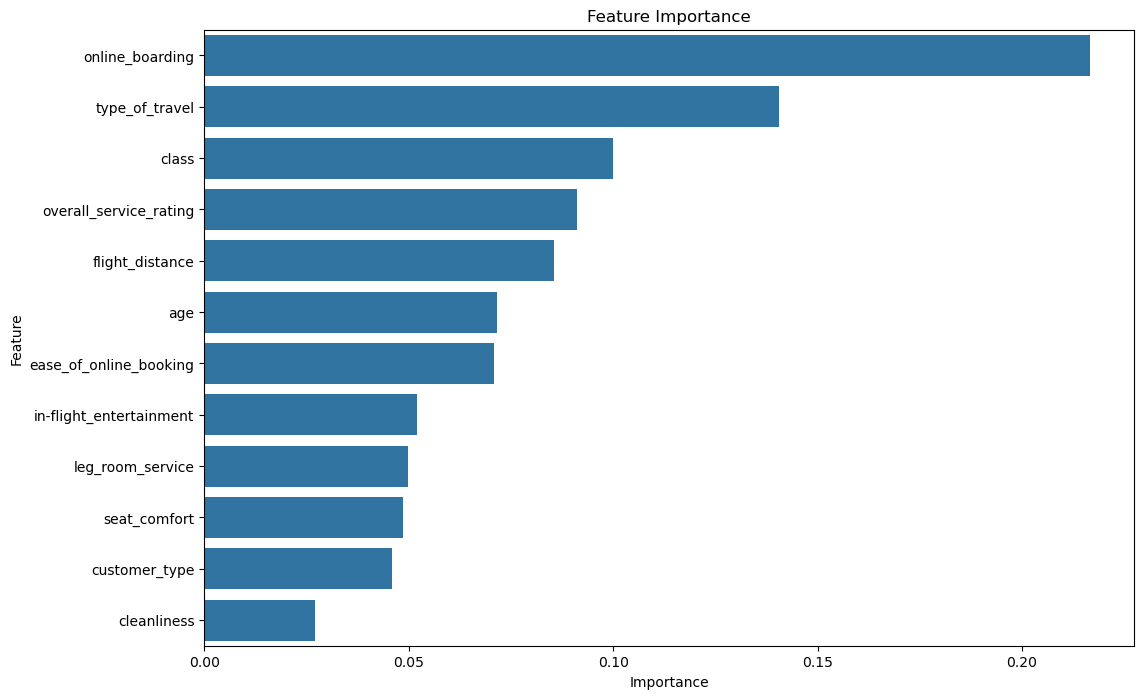

In [176]:
# Plot Feature Importance

plt.figure(figsize=(12,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [177]:
## Step 3: Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

In [178]:
# Parameter Grid

param_grid = {

    'n_estimators': [50, 100],

    'max_depth': [5, 10],

    'min_samples_split': [2, 5]
}

In [179]:
# GridSearchCV

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=3,

    scoring='accuracy',

    n_jobs=-1
)

In [180]:
# Train GridSearchCV

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy')

In [181]:
# Best Parameters

grid_search.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

In [182]:
# Best Score

grid_search.best_score_

np.float64(0.9250703496958902)

In [148]:
### Step 4: Build Final Model

In [149]:
# Final Model

final_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=10,

    min_samples_split=2,

    random_state=42
)

In [150]:
# Train Final Model

final_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

### Step 5: Final Evaluation

In [151]:
# Predictions

y_pred_final = final_model.predict(X_test)

In [152]:
# Accuracy Score

from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

print("Final Model Accuracy :", final_accuracy)

Final Model Accuracy : 0.922747068676717


In [153]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_final
))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      7369
           1       0.94      0.91      0.92      7556

    accuracy                           0.92     14925
   macro avg       0.92      0.92      0.92     14925
weighted avg       0.92      0.92      0.92     14925



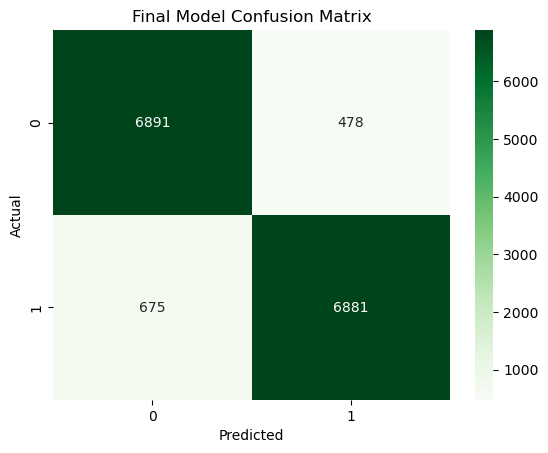

In [154]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_final
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Final Model Confusion Matrix")

plt.show()

### Step 6: Model Serialization

In [155]:
# Save Model

import joblib

joblib.dump(
    final_model,
    "airline_satisfaction_model.pkl"
)

['airline_satisfaction_model.pkl']

In [156]:
import joblib

joblib.dump(best_model, "airline_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### Sprint - 4

In [157]:
# Import Libraries 

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [158]:
# Create Pipeline

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

In [159]:
# Train Pipeline

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [160]:
# Pipeline Prediction

pipeline_pred = pipeline.predict(X_test)

In [161]:
# Pipeline Accuracy

from sklearn.metrics import accuracy_score

pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_pred
)

print("Pipeline Accuracy :", pipeline_accuracy)

Pipeline Accuracy : 0.922747068676717


In [162]:
# Save Pipeline

import joblib

joblib.dump(
    pipeline,
    "airline_pipeline.pkl"
)

['airline_pipeline.pkl']

In [163]:
print(scaler.n_features_in_)

13


In [164]:
model = joblib.load("airline_model.pkl")
scaler = joblib.load("scaler.pkl")

print(scaler.n_features_in_)

13
